# import

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from cycler import cycler
from datetime import timedelta
import datetime

# ========= 1) 读取 Excel =========
xls_path = r'C:/Users/fengxiang.mao/Desktop/HFTS2_dataset/optasense-hfp-cwc_zip_b/Anadarko_B2H_(B3H)_CWC/Input/Curves/complimentory_2.xlsx'          # ← 替换为你的文件路径
sheet = 0                             # 或者工作表名，例如 "Sheet1"
df = pd.read_excel(xls_path, sheet_name=sheet, engine="openpyxl")

# 统一列名（去空格、大小写），兼容 "Slurry rate" / "Slurryrate"
df = df.rename(columns={c: c.strip().lower().replace(" ", "") for c in df.columns})

# 期望有：date, whp, slurryrate, concentration
required = {"date", "whp", "slurryrate", "concentration"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Excel 缺少列: {missing}")

# 时间戳（毫秒）→ pandas datetime（注意：若是秒，把 unit='s'）
t = pd.to_datetime(df["date"], unit="ms")  #<class 'pandas.core.series.Series'>       # , utc=True).tz_convert("America/Chicago"
whp = df["whp"].astype(float)
rate = df["slurryrate"].astype(float)
conc = df["concentration"].astype(float)


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/fengxiang.mao/Desktop/HFTS2_dataset/optasense-hfp-cwc_zip_b/Anadarko_B2H_(B3H)_CWC/Input/Curves/complimentory_2.xlsx'

# S6

In [34]:
length = len(t)
print(f"读取 {length} 条记录")
#取部分数据进行绘图

# ---- 3) 设定你要显示的时间段（同一时区！）----
start = pd.Timestamp("2019-04-01 18:05:27")
end   = pd.Timestamp("2019-04-02 01:10:27")

mask = (t >= start) & (t <= end)

t_sel    = t[mask]
whp_sel  = whp[mask]
rate_sel = rate[mask]
conc_sel = conc[mask]

#whp from kpa to psi
whp_sel = whp_sel * 0.145038
#rate from "m3/min" to "bbl/min"
rate_sel = rate_sel * 6.28981
#conc from "kg/m3" to (lbm/gal)
conc_sel = conc_sel 

print(mask)
print(len(conc_sel))
print(len(t_sel))
print(len(whp_sel))
print(len(rate_sel))

读取 714285 条记录
0         False
1         False
2         False
3         False
4         False
          ...  
714280    False
714281    False
714282    False
714283    False
714284    False
Name: date, Length: 714285, dtype: bool
25324
25324
25324
25324


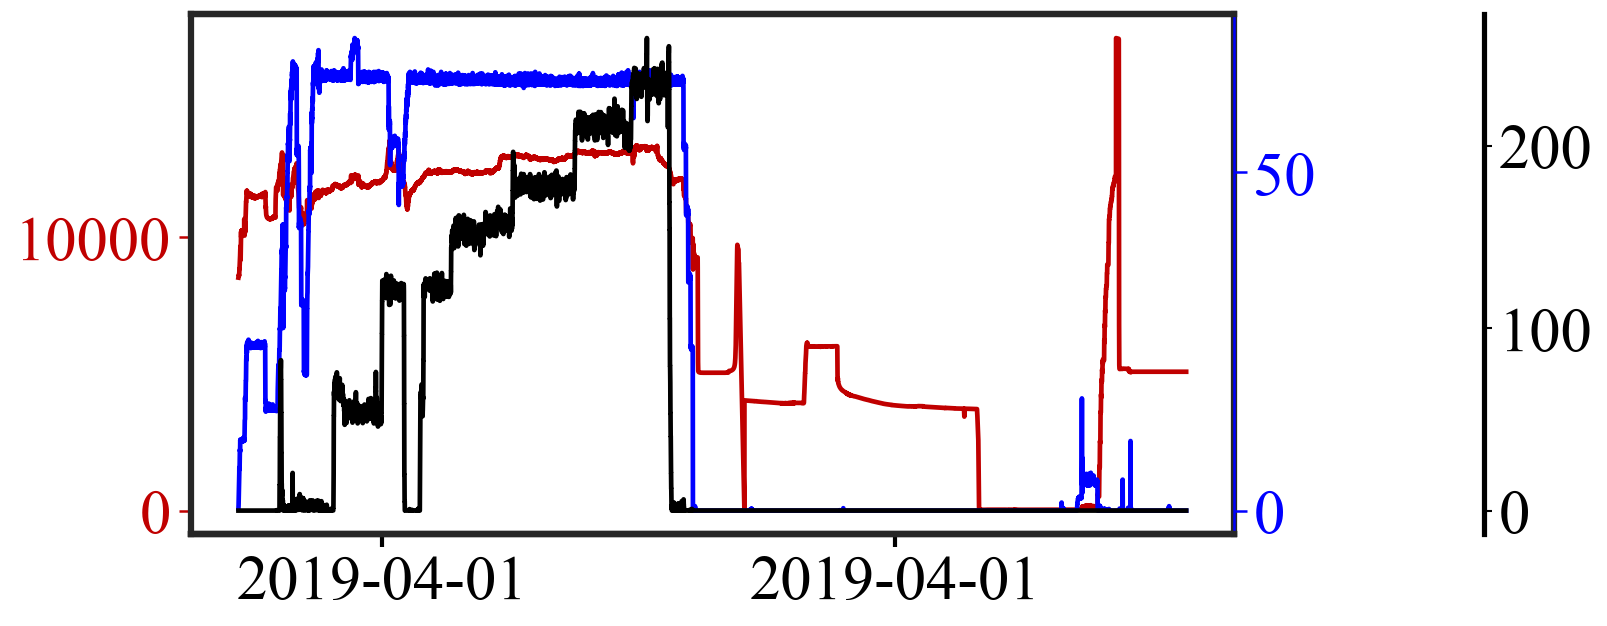

In [ ]:

# ========= 2) 画图对象 =========
rc = {'axes.facecolor':'white',
      'figure.figsize': (12, 6),
      'savefig.dpi': 600,
#       'axes.grid' : False,
      'axes.edgecolor' : '0.15',
      
      'font.family':'Times New Roman',
      'font.serif': ['Times New Roman', 'Times', 'STIXGeneral'],  # 备选
      # —— 数学字体（$...$ 内）——
      'mathtext.fontset': 'stix',     # 关键：让 μ、ε 等用 STIX（Times 风格）
      'axes.unicode_minus': False,    # 让负号显示为正常的连字符


      'axes.labelsize': 36,         # X、Y 轴标题字体
      'axes.labelweight': 'bold',   # X、Y 轴标题加粗
      'xtick.labelsize': 30,        # X轴刻度文字
      'ytick.labelsize': 30,        # Y轴刻度文字
      'legend.fontsize': 30,       # 图例字体

      # 线宽与颜色顺序
      'lines.linewidth': 2.25,      # 所有线条默认 2.25 pt
      'axes.prop_cycle': cycler('color', list(('k', 'r', 'b', 'g', 'm', 'c', 'y'))),

      # 刻度朝外 & 粗细
      'xtick.direction': 'out',
      'ytick.direction': 'out',
      'xtick.major.size': 6,
      'ytick.major.size': 6,
      'xtick.major.width': 2.0,
      'ytick.major.width': 2.0,

      # 坐标轴（内框）线宽
      'axes.linewidth': 3.0,
      } 
# lack of font size
plt.rcParams.update(rc)

fig, ax1 = plt.subplots(figsize=(10, 4.5), dpi=150)

# 第二 y 轴（右）
ax2 = ax1.twinx()
# 第三 y 轴（再往外偏移 60pt）
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 120))  # 关键：把第三轴移到外侧
ax3.set_frame_on(True)
ax3.patch.set_visible(False)  # 不遮挡主绘图区

# ========= 3) 绘制三条曲线 =========
c1, c2, c3 = "#C00000", "blue", "black"

l1, = ax1.plot(t_sel, whp_sel, color=c1, lw=2.25, label="Treating pressure (psi)")
l2, = ax2.plot(t_sel, rate_sel, color=c2, lw=2.25, label="Slurry rate (bbl/min)")
l3, = ax3.plot(t_sel, conc_sel, color=c3, lw=2.25, label="Proppant conc (lbm/gal)")

# ========= 4) 轴与刻度样式 =========
# ---- y 轴颜色统一（标签、刻度、脊线）----
# 左轴（红）
# ax1.set_ylabel("Treating pressure (psi)", color=c1)
ax1.tick_params(axis="y", colors=c1, width=1.2)
ax1.spines["left"].set_color(c1)
ax1.spines["left"].set_linewidth(1.2)
#set y axis limits
# ax1.set_ylim(-1000, 18000)
# #set y axis ticks
ax1.set_yticks([0, 10000])                     # 位置（数据坐标）
# ax1.set_yticklabels(['0', '4000', '8000', '12000', '16000'])     # 文本（与上面位置一一对应）

# 右轴（蓝）← 你关心的部分
# ax2.set_ylabel("Slurry rate (bbl/min)", color=c2)
ax2.tick_params(axis="y", colors=c2, width=1.2)          # 刻度线/文字变蓝
ax2.spines["right"].set_color(c2)                        # 右侧竖线变蓝
ax2.spines["right"].set_linewidth(1.2)
# ax2.set_ylim(-1000, 18000)
# #set y axis ticks
ax2.set_yticks([0, 50])                     # 位置（数据坐标）

# 外侧第三轴（黑）
# ax3.set_ylabel("Proppant conc (lbm/gal)", color=c3, rotation=90, labelpad=30)
ax3.tick_params(axis="y", colors=c3, width=1.2)
ax3.spines["right"].set_color(c3)
ax3.spines["right"].set_linewidth(2.5)
ax3.set_yticks([0, 100, 200])

# 让第三轴看起来是“外侧的一条竖线带刻度”
for side in ["left", "top"]:
    ax3.spines[side].set_visible(False)   # 只保留外侧这条右边竖线
ax3.spines["right"].set_color(c3)
ax3.tick_params(axis="y", length=4, width=1.0, colors=c3)

# x 轴时间格式（示例：mm-dd hh）
# ax1.xaxis.set_major_formatter(mdates.DateFormatter("%y/%m/%d\n%H:%M:%S.{ms})"))
# ax1.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=2, maxticks=2))
# fig.autofmt_xdate()  # 倾斜以防重叠
# ax1.set_xlabel("Time mm-dd hh")


ax1.set_xticks([datetime.datetime(2019,4,1,19,10,00),datetime.datetime(2019,4,1,23,00,00)])                   # 位置（数据坐标）
ax1.set_xticklabels(['2019-04-01','2019-04-01'])     # 文本（与上面位置一一对应）
# ax.set_yticks([13600, 13800, 14000, 14200, 14400])                     # 位置（数据坐标）
# ax.set_yticklabels(['13600', '13800', '14000', '14200', '14400'])     # 文本（与上面位置一一对应）





# 网格（仅主轴网格，避免太花）
# ax1.grid(True, linestyle="--", alpha=0.3)

# ========= 5) 图例（合并三条线） =========
# lines = [l1, l2, l3]
# labels = [ln.get_label() for ln in lines]
# ax1.legend(lines, labels, loc="upper left", frameon=False)

# 给外侧轴留空间，避免被裁切
fig.subplots_adjust(right=0.82)
plt.savefig('frac_curves_S6.png', dpi=600, bbox_inches='tight')
plt.show()



# S22

In [36]:
length = len(t)
print(f"读取 {length} 条记录")
#取部分数据进行绘图

# ---- 3) 设定你要显示的时间段（同一时区！）----
start = pd.Timestamp("2019-04-07 03:31:27")
end   = pd.Timestamp("2019-04-07 09:00:27")

mask = (t >= start) & (t <= end)

t_sel    = t[mask]
whp_sel  = whp[mask]
rate_sel = rate[mask]
conc_sel = conc[mask]

#whp from kpa to psi
whp_sel = whp_sel * 0.145038
#rate from "m3/min" to "bbl/min"
rate_sel = rate_sel * 6.28981
#conc from "kg/m3" to (lbm/gal)
conc_sel = conc_sel 

print(mask)
print(len(conc_sel))
print(len(t_sel))
print(len(whp_sel))
print(len(rate_sel))

读取 714285 条记录
0         False
1         False
2         False
3         False
4         False
          ...  
714280    False
714281    False
714282    False
714283    False
714284    False
Name: date, Length: 714285, dtype: bool
19533
19533
19533
19533


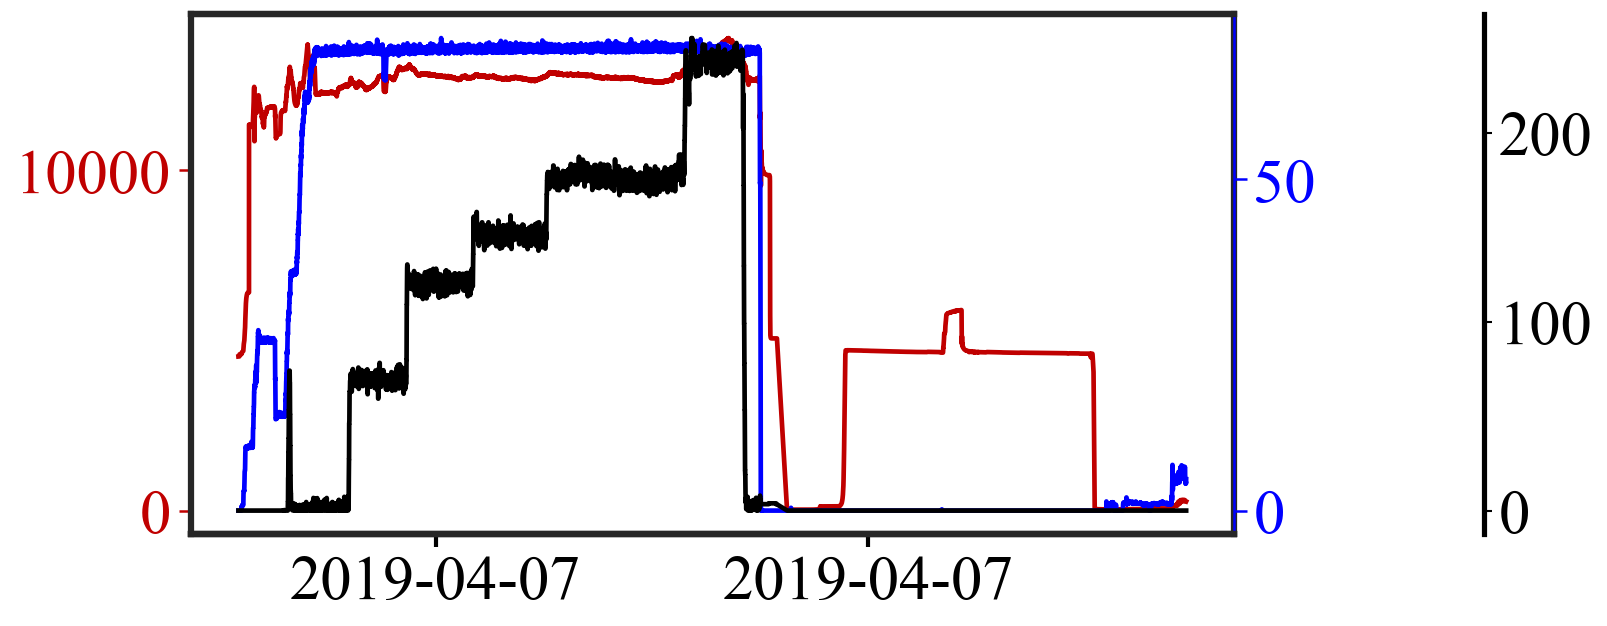

In [37]:

# ========= 2) 画图对象 =========
rc = {'axes.facecolor':'white',
      'figure.figsize': (12, 6),
      'savefig.dpi': 600,
#       'axes.grid' : False,
      'axes.edgecolor' : '0.15',
      
      'font.family':'Times New Roman',
      'font.serif': ['Times New Roman', 'Times', 'STIXGeneral'],  # 备选
      # —— 数学字体（$...$ 内）——
      'mathtext.fontset': 'stix',     # 关键：让 μ、ε 等用 STIX（Times 风格）
      'axes.unicode_minus': False,    # 让负号显示为正常的连字符


      'axes.labelsize': 36,         # X、Y 轴标题字体
      'axes.labelweight': 'bold',   # X、Y 轴标题加粗
      'xtick.labelsize': 30,        # X轴刻度文字
      'ytick.labelsize': 30,        # Y轴刻度文字
      'legend.fontsize': 30,       # 图例字体

      # 线宽与颜色顺序
      'lines.linewidth': 3,      # 所有线条默认 2.25 pt
      'axes.prop_cycle': cycler('color', list(('k', 'r', 'b', 'g', 'm', 'c', 'y'))),

      # 刻度朝外 & 粗细
      'xtick.direction': 'out',
      'ytick.direction': 'out',
      'xtick.major.size': 6,
      'ytick.major.size': 6,
      'xtick.major.width': 2.0,
      'ytick.major.width': 2.0,

      # 坐标轴（内框）线宽
      'axes.linewidth': 3.0,
      } 
# lack of font size
plt.rcParams.update(rc)

fig, ax1 = plt.subplots(figsize=(10, 4.5), dpi=150)

# 第二 y 轴（右）
ax2 = ax1.twinx()
# 第三 y 轴（再往外偏移 60pt）
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 120))  # 关键：把第三轴移到外侧
ax3.set_frame_on(True)
ax3.patch.set_visible(False)  # 不遮挡主绘图区

# ========= 3) 绘制三条曲线 =========
c1, c2, c3 = "#C00000", "blue", "black"

l1, = ax1.plot(t_sel, whp_sel, color=c1, lw=2.25, label="Treating pressure (psi)")
l2, = ax2.plot(t_sel, rate_sel, color=c2, lw=2.25, label="Slurry rate (bbl/min)")
l3, = ax3.plot(t_sel, conc_sel, color=c3, lw=2.25, label="Proppant conc (lbm/gal)")

# ========= 4) 轴与刻度样式 =========
# ---- y 轴颜色统一（标签、刻度、脊线）----
# 左轴（红）
# ax1.set_ylabel("Treating pressure (psi)", color=c1)
ax1.tick_params(axis="y", colors=c1, width=1.2)
ax1.spines["left"].set_color(c1)
ax1.spines["left"].set_linewidth(1.2)
#set y axis limits
# ax1.set_ylim(-1000, 18000)
# #set y axis ticks
ax1.set_yticks([0, 10000])                     # 位置（数据坐标）
# ax1.set_yticklabels(['0', '4000', '8000', '12000', '16000'])     # 文本（与上面位置一一对应）

# 右轴（蓝）← 你关心的部分
# ax2.set_ylabel("Slurry rate (bbl/min)", color=c2)
ax2.tick_params(axis="y", colors=c2, width=1.2)          # 刻度线/文字变蓝
ax2.spines["right"].set_color(c2)                        # 右侧竖线变蓝
ax2.spines["right"].set_linewidth(1.2)
# ax2.set_ylim(-1000, 18000)
# #set y axis ticks
ax2.set_yticks([0, 50])                     # 位置（数据坐标）

# 外侧第三轴（黑）
# ax3.set_ylabel("Proppant conc (lbm/gal)", color=c3, rotation=90, labelpad=30)
ax3.tick_params(axis="y", colors=c3, width=1.2)
ax3.spines["right"].set_color(c3)
ax3.spines["right"].set_linewidth(2.5)
ax3.set_yticks([0, 100, 200])

# 让第三轴看起来是“外侧的一条竖线带刻度”
for side in ["left", "top"]:
    ax3.spines[side].set_visible(False)   # 只保留外侧这条右边竖线
ax3.spines["right"].set_color(c3)
ax3.tick_params(axis="y", length=4, width=1.0, colors=c3)


# x 轴时间格式（示例：mm-dd hh）
# ax1.xaxis.set_major_formatter(mdates.DateFormatter("%y/%m/%d\n%H:%M:%S.{ms})"))
# ax1.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=2, maxticks=2))
# fig.autofmt_xdate()  # 倾斜以防重叠
# ax1.set_xlabel("Time mm-dd hh")


ax1.set_xticks([datetime.datetime(2019,4,7,4,40,00),datetime.datetime(2019,4,7,7,10,00)])                   # 位置（数据坐标）
ax1.set_xticklabels(['2019-04-07','2019-04-07'])     # 文本（与上面位置一一对应）
# ax.set_yticks([13600, 13800, 14000, 14200, 14400])                     # 位置（数据坐标）
# ax.set_yticklabels(['13600', '13800', '14000', '14200', '14400'])     # 文本（与上面位置一一对应）





# 网格（仅主轴网格，避免太花）
# ax1.grid(True, linestyle="--", alpha=0.3)

# ========= 5) 图例（合并三条线） =========
# lines = [l1, l2, l3]
# labels = [ln.get_label() for ln in lines]
# ax1.legend(lines, labels, loc="upper left", frameon=False)

# 给外侧轴留空间，避免被裁切
fig.subplots_adjust(right=0.82)
plt.savefig('frac_curves_S22.png', dpi=600, bbox_inches='tight')
plt.show()



# HFTS-1 Evo-7 pressure

In [29]:
%reload_ext autoreload
%autoreload 2

import numpy as np
from plot_style import *
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from cycler import cycler
from datetime import timedelta
import datetime

# ========= 1) 读取 Excel =========
xls_path = r'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 7 (flowback)/13004.xlsx'          # ← 替换为你的文件路径

sheet = 0                             # 或者工作表名，例如 "Sheet1"
df = pd.read_excel(xls_path, sheet_name=sheet, engine="openpyxl")

# 统一列名（去空格、大小写），兼容 "Slurry rate" / "Slurryrate"
df = df.rename(columns={c: c.strip().lower().replace(" ", "") for c in df.columns})

# 期望有：date, whp, slurryrate, concentration
required = {"date", "pressure"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Excel 缺少列: {missing}")

# 时间戳（毫秒）→ pandas datetime（注意：若是秒，把 unit='s'）
t_1 = pd.to_datetime(df["date"], unit="s")  #<class 'pandas.core.series.Series'>       # , utc=True).tz_convert("America/Chicago"
pressure_1 = df["pressure"].astype(float)

#========================= read excel 2 =========
xls_path2 = r'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 7 (flowback)/15321.xlsx'           # ← 替换为你的文件路径
sheet2 = 0                             # 或者工作表名，例如 "Sheet1"
df2 = pd.read_excel(xls_path2, sheet_name=sheet2, engine="openpyxl")

# 统一列名（去空格、大小写），兼容 "Slurry rate" / "Slurryrate"
df2 = df2.rename(columns={c: c.strip().lower().replace(" ", "") for c in df2.columns})

# 期望有：date, whp, slurryrate, concentration
required2 = {"date", "pressure"}
missing2 = required2 - set(df2.columns)
if missing2:
    raise ValueError(f"Excel 缺少列: {missing2}")

# 时间戳（毫秒）→ pandas datetime（注意：若是秒，把 unit='s'）
t_2 = pd.to_datetime(df2["date"], unit="s")  #<class 'pandas.core.series.Series'>       # , utc=True).tz_convert("America/Chicago"
pressure_2 = df2["pressure"].astype(float)


In [30]:
length = len(t_1)
print(f"读取 {length} 条记录")
#取部分数据进行绘图

# ---- 3) 设定你要显示的时间段（同一时区！）----
start = pd.Timestamp("2022-05-31 12:00:00")
end   = pd.Timestamp("2022-06-08 06:00:00")

mask_1 = (t_1 >= start) & (t_1 <= end)
mask_2 = (t_2 >= start) & (t_2 <= end)

t_sel_1    = t_1[mask_1]
t_sel_2    = t_2[mask_2]

pressure_sel_1  = pressure_1[mask_1]
pressure_sel_2  = pressure_2[mask_2]


# print(mask_1)
print(len(pressure_sel_1))
print(len(t_sel_1))
print(len(pressure_sel_2))
print(len(t_sel_2))

读取 128 条记录
123
123
142
142


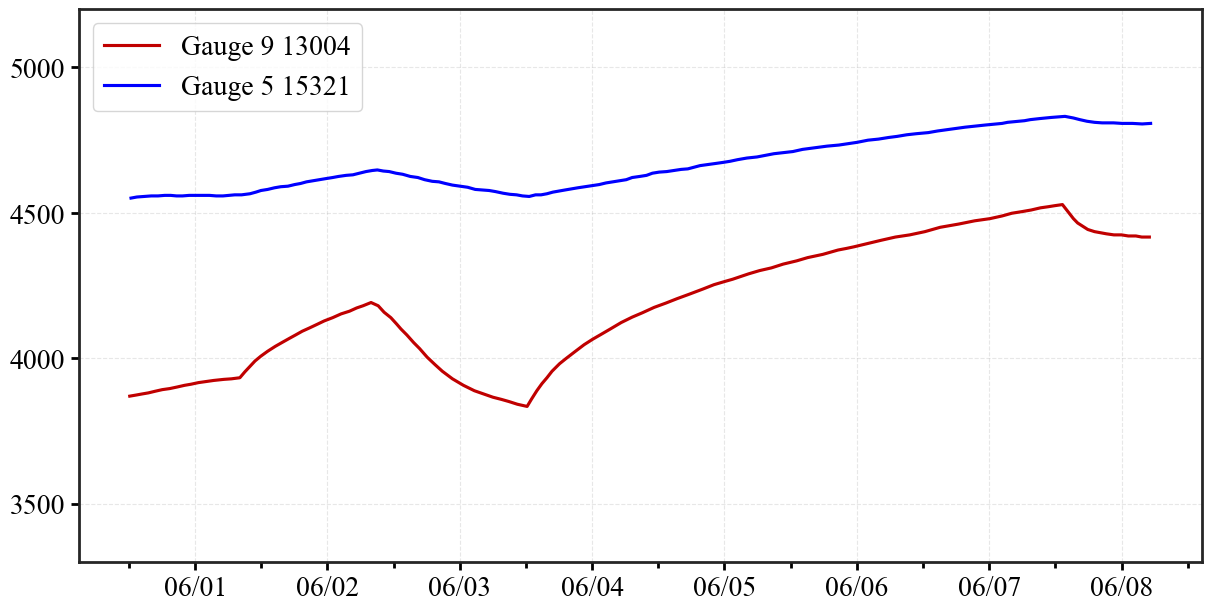

In [37]:

# ========= 2) 画图对象 =========
rc = {'axes.facecolor':'white',
      'figure.figsize': (12, 6),
      'savefig.dpi': 600,
#       'axes.grid' : False,
      'axes.edgecolor' : '0.15',
      
      'font.family':'Times New Roman',
      'font.serif': ['Times New Roman', 'Times', 'STIXGeneral'],  # 备选
      # —— 数学字体（$...$ 内）——
      'mathtext.fontset': 'stix',     # 关键：让 μ、ε 等用 STIX（Times 风格）
      'axes.unicode_minus': False,    # 让负号显示为正常的连字符
      
      'axes.labelsize': 36,         # X、Y 轴标题字体
      'axes.labelweight': 'bold',   # X、Y 轴标题加粗
      'xtick.labelsize': 36,        # X轴刻度文字
      'ytick.labelsize': 36,        # Y轴刻度文字
      'legend.fontsize': 36,       # 图例字体

      # 线宽与颜色顺序
      'lines.linewidth': 2.25,      # 所有线条默认 2.25 pt
      'axes.prop_cycle': cycler('color', list(('k', 'r', 'b', 'g', 'm', 'c', 'y'))),

      # 刻度朝外 & 粗细
      'xtick.direction': 'out',
      'ytick.direction': 'out',
      'xtick.major.size': 6,
      'ytick.major.size': 6,
      'xtick.major.width': 2.0,
      'ytick.major.width': 2.0,

      # 坐标轴（内框）线宽
      'axes.linewidth': 4.0,
      } 
# lack of font size
plt.rcParams.update(rc)

fig, ax1 = make_standard_figure(figsize=(12 , 6))

# ========= 3) 绘制三条曲线 =========
c1, c2 = "#C00000", "blue"

l1, = ax1.plot(t_sel_1, pressure_sel_1, color=c1, lw=2.25, label="Gauge 9 13004")
l2, = ax1.plot(t_sel_2, pressure_sel_2, color=c2, lw=2.25, label="Gauge 5 15321")


# ========= 4) 轴与刻度样式 =========
# ---- y 轴颜色统一（标签、刻度、脊线）----
# 左轴（红）
# ax1.set_ylabel("Treating pressure (psi)", color=c1)
# ax1.tick_params(axis="y", colors=c1, width=1.2)
# ax1.spines["left"].set_color(c1)
# ax1.spines["left"].set_linewidth(1.2)
#set y axis limits
ax1.set_ylim(3300, 5200)
ax1.set_yticks(range(3500, 5001, 500))

# #set y axis ticks
# ax1.set_yticks([3500, 5500])                     # 位置（数据坐标）
# ax1.set_yticklabels(['0', '4000', '8000', '12000', '16000'])     # 文本（与上面位置一一对应）

# 右轴（蓝）← 你关心的部分
# ax2.set_ylabel("Slurry rate (bbl/min)", color=c2)
# ax2.tick_params(axis="y", colors=c2, width=1.2)          # 刻度线/文字变蓝
# ax2.spines["right"].set_color(c2)                        # 右侧竖线变蓝
# ax2.spines["right"].set_linewidth(1.2)
# # ax2.set_ylim(-1000, 18000)
# # #set y axis ticks
# ax2.set_yticks([0, 50])                     # 位置（数据坐标）

# 外侧第三轴（黑）
# ax3.set_ylabel("Proppant conc (lbm/gal)", color=c3, rotation=90, labelpad=30)
# ax3.tick_params(axis="y", colors=c3, width=1.2)
# ax3.spines["right"].set_color(c3)
# ax3.spines["right"].set_linewidth(2.5)
# ax3.set_yticks([0, 100, 200])

# 让第三轴看起来是“外侧的一条竖线带刻度”
# for side in ["left", "top"]:
#     ax3.spines[side].set_visible(False)   # 只保留外侧这条右边竖线
# ax3.spines["right"].set_color(c3)
# ax3.tick_params(axis="y", length=4, width=1.0, colors=c3)

# x 轴时间格式（示例：mm-dd hh）
# ax1.xaxis.set_major_formatter(mdates.DateFormatter("%y/%m/%d\n%H:%M:%S.{ms})"))
# ax1.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=2, maxticks=2))
# fig.autofmt_xdate()  # 倾斜以防重叠
# ax1.set_xlabel("Time mm-dd hh")


# ax1.set_xticks([datetime.datetime(2019,4,1,19,10,00),datetime.datetime(2019,4,1,23,00,00)])                   # 位置（数据坐标）
# ax1.set_xticklabels(['2019-04-01','2019-04-01'])     # 文本（与上面位置一一对应）
# ax.set_yticks([13600, 13800, 14000, 14200, 14400])                     # 位置（数据坐标）
# ax.set_yticklabels(['13600', '13800', '14000', '14200', '14400'])     # 文本（与上面位置一一对应）
import pandas as pd

ticks = pd.date_range(start='2022-06-01', end='2022-06-08', freq='24h')

ax1.set_xticks(ticks)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

from matplotlib.ticker import AutoMinorLocator

ax1.xaxis.set_minor_locator(AutoMinorLocator(2)) 



# 网格（仅主轴网格，避免太花）
ax1.grid(True, linestyle="--", alpha=0.3)

# ========= 5) 图例（合并三条线） =========
# lines = [l1, l2, l3]
# labels = [ln.get_label() for ln in lines]
ax1.legend(loc="upper left")

# 给外侧轴留空间，避免被裁切
# fig.subplots_adjust(right=0.82)
# plt.savefig('frac_curves_S6.png', dpi=600, bbox_inches='tight')
plt.show()



# pressure and strain change

C:\Users\fengxiang.mao\AppData\Local\Temp\ipykernel_13684\2794288569.py:186: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


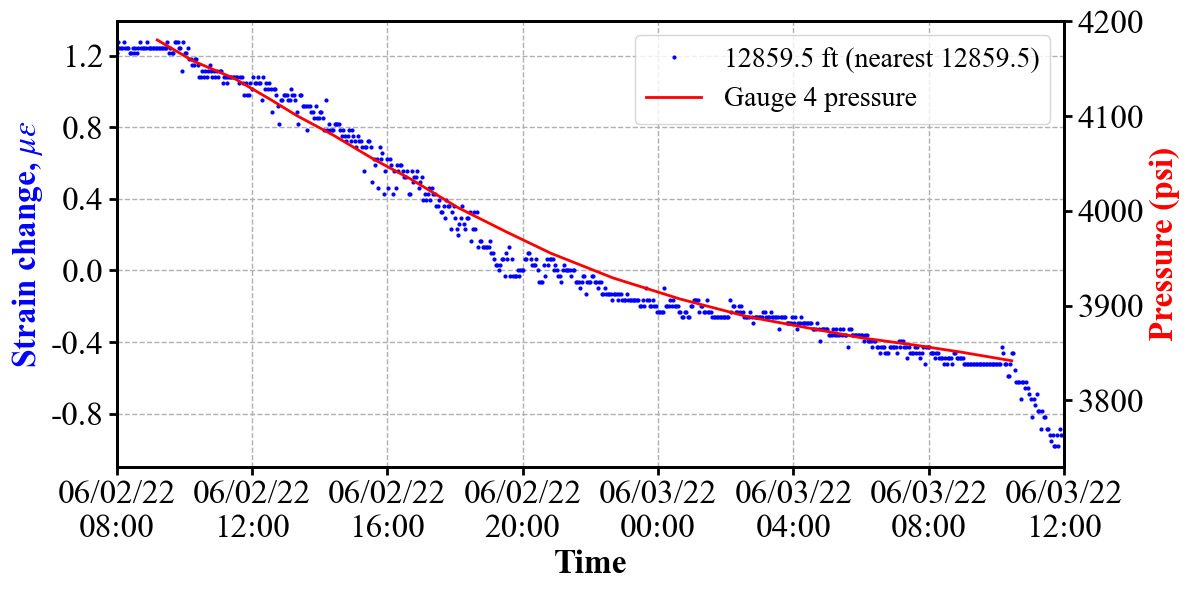

In [16]:
%reload_ext autoreload
%autoreload 2

from turtle import color
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dateutil.rrule import HOURLY
from plot_style import plot_strain_vs_time_at_depths, decode_stamps_to_datetimeindex, make_standard_figure

# =======================
# A) 读 strain (H5)
# =======================
h5_path = r'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 7 (flowback)/corrected_within_1h_(with_data_wash).h5'
f1 = h5py.File(h5_path, 'r')

dstrain = f1['strain_corrected']   # (Nt, Nz)
depth   = f1['depth']
stamps  = f1['stamps']

stamps_idx = decode_stamps_to_datetimeindex(stamps, fmt='%m/%d/%Y %H:%M:%S.%f') if stamps is not None else None

# 你选的深度（仍然按“最近深度列”匹配）
depth_range = np.array([12859.5]) #Gauge 9
# depth_range = np.array([15176.5]) #Gauge 4

#------------------gauge 4----------------

#a)
# 15137.2, 15137.5, 15137.8, 15138.2, 15138.5, 15138.8
#b)
# 15148.4, 15148.7, 15149.1, 15149.4, 15149.7, 15150.1, 15150.4, 15150.7, 15151.1, 15151.4, 15151.7, 15152.1, 15152.4, 15152.7
#c)
# 15167.3, 15167.6, 15167.9, 15168.3, 15168.6, 15168.9, 15169.2, 15169.6, 15169.9
#d)
# 15174.9, 15175.2, 15175.5, 15175.9, 15176.2, 15176.5, 15176.9, 15177.2, 15177.5, 15177.8, 15178.2, 15178.5, 15178.8


#----------gauge 9 ------------------
#12858.5, 12858.8, 12859.2, 12859.5, 12859.8,
#12860.1, 12860.5, 12860.8, 12861.1, 12861.5
#12861.8, 12862.1, 12862.5, 12862.8, 12863.1
#12863.5, 12863.8, 12864.1, 12864.5, 12864.8
#12865.1, 12865.5, 12865.8, 12866.1, 12866.5
#12866.8, 12867.1, 12867.4, 12867.8, 12868.1
#12868.4, 12868.8, 12869.1, 12869.4, 12869.7
#12870.1, 12870.4, 12870.8, 12871.1, 12871.4
#12871.7, 12872.1, 12872.4, 12872.8, 12873.1
#12873.4, 12873.7, 12874.1, 12874.4, 12874.7
#12875.1, 12875.4, 12875.7, 12876.1


# 时间窗口
tmin = "2022-06-02 08:00:00"
tmax = "2022-06-03 12:00:00"

# =======================
# B) 读 Gauge 9 pressure (xlsx)
# =======================
xls_path_g9 = r'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 7 (flowback)/13004.xlsx'
# xls_path_g9 = r'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 7 (flowback)/15321.xlsx'           # ← 替换为你的文件路径


df = pd.read_excel(xls_path_g9, sheet_name=0, engine="openpyxl")
df = df.rename(columns={c: c.strip().lower().replace(" ", "") for c in df.columns})

required = {"date", "pressure"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Excel 缺少列: {missing}")

t_p = pd.to_datetime(df["date"], unit="s")   # 你前面是 unit="s"
p   = df["pressure"].astype(float)

# 对齐同一时间窗口
start = pd.to_datetime(tmin)
end   = pd.to_datetime(tmax)
mask_p = (t_p >= start) & (t_p <= end)
t_p_sel = t_p[mask_p]
p_sel   = p[mask_p]

# =======================
# C) 先画左轴 strain（用你现成函数）
# =======================
fig, ax1 = plot_strain_vs_time_at_depths(
    dstrain, depth,
    stamps_index=stamps_idx,
    target_depths=depth_range,
    time_window=(tmin, tmax),
    scale=1.0,
    strain_unit="(microstrain)",
    figsize=(12, 6), grid=True, legend='auto',
    time_format='%m/%d\n %H:%M',
    legend_labels=[f"{d} ft" for d in depth_range],
)

# 把 strain 画成散点（左轴）
for ln in ax1.lines:
    ln.set_linestyle('None')
    ln.set_marker('o')
    ln.set_markersize(2)
    ln.set_markerfacecolor('blue')
    ln.set_markeredgecolor('blue')

# 重新画 legend（确保样式同步）
leg = ax1.get_legend()
if leg is not None:
    leg.remove()
ax1.legend(loc="upper left", ncol=1)

# 左轴标签（你想更明确的话）
ax1.set_ylabel(r"Strain change, $\mu\varepsilon$", color="blue")

# =======================
# D) 右轴叠加 pressure
# =======================
ax2 = ax1.twinx()
ax2.plot(t_p_sel, p_sel, color="red", lw=2.0, label="Gauge 4 pressure")

ax2.set_ylabel("Pressure (psi)", color="red")
# 如果你想定范围（按你之前的 pressure 图）
# ax2.set_ylim(3300, 5200)
# ax2.set_yticks(range(3500, 5001, 500))

# =======================
# E) 统一 x 轴范围、ticks、竖线
# =======================
xmin = pd.to_datetime(tmin)
xmax = pd.to_datetime(tmax)
ax1.set_xlim(xmin, xmax)

# ticks：每天一个主刻度，从 06/01 00:00 开始
tick_start = pd.to_datetime("2022-06-01 00:00:00")
rule = mdates.rrulewrapper(HOURLY, interval=4, dtstart=tick_start.to_pydatetime())
ax1.xaxis.set_major_locator(mdates.RRuleLocator(rule))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d/%y\n%H:%M'))
# ax1.xaxis.set_minor_locator(mdates.HourLocator(interval=12))
# ax1.xaxis.set_minor_locator(mdates.HourLocator(interval=4))

# 两条竖线
t1 = pd.to_datetime("2022-06-02 08:00:00")
t2 = pd.to_datetime("2022-06-03 12:00:00")
ax1.axvline(t1, linestyle="--", linewidth=2, alpha=0.9, color='black')
ax1.axvline(t2, linestyle="--", linewidth=2, alpha=0.9, color='black')



# =======================
# 可调参数：y 轴范围（设为 None 表示不强制）
# =======================
# strain_ylim   = (-1, 2)        # 左轴 strain (None 或 (ymin, ymax))
# pressure_ylim = (3710, 4230)    # 右轴 pressure (None 或 (ymin, ymax))   Gauge9
pressure_ylim = (3730, 4200)    # 右轴 pressure (None 或 (ymin, ymax))   Gauge9  -zoom-v2

# 可选：y 轴刻度（设为 None 表示自动）
# strain_yticks   = None#np.arange(-5, 15.1, 5)     # 或 None
pressure_yticks = None# np.arange(3300, 5200.1, 500)  # 或 None

# =======================
# 应用到两条轴
# =======================
# if strain_ylim is not None:
#     ax1.set_ylim(*strain_ylim)
# if strain_yticks is not None:
#     ax1.set_yticks(strain_yticks)

if pressure_ylim is not None:
    ax2.set_ylim(*pressure_ylim)
if pressure_yticks is not None:
    ax2.set_yticks(pressure_yticks)



# 网格
ax1.grid(True, linestyle='--')

# =======================
# F) 合并左右轴 legend
# =======================
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right", ncol=1)

plt.tight_layout()
plt.show()


# 11